In [ ]:

# current pipeline state

Raw Data
   ↓
Signals
   ↓
Events
   ↓
Context Builder
   ├── Company Profile
   ├── Portfolio
   ├── Goals
   └── Constraints
   ↓
Prompt Builder
   ↓
LLM
   ↓
Retrieval Request



In [1]:
!pip install yfinance pandas numpy scikit-learn tqdm

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.ensemble import IsolationForest

import numpy as np

import matplotlib
import matplotlib.pyplot as plt

In [3]:
TICKERS = [
    "AAPL","MSFT","NVDA","AMZN","GOOGL","META","TSLA","BRK-B","JPM","V",
    "UNH","XOM","MA","AVGO","PG","HD","LLY","MRK","COST","PEP",
    "ADBE","CSCO","KO","CRM","WMT","BAC","NFLX","TMO","DIS","ABT"
]

In [4]:
def load_data(tickers, period="24mo", interval="1d"):
    data = yf.download(
        tickers,
        period=period,
        interval=interval,
        auto_adjust=True
    )["Close"]

    data = data.dropna(axis=1, how="all")
    return data

prices = load_data(TICKERS)
prices.head()

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,ABT,ADBE,AMZN,AVGO,BAC,BRK-B,COST,CRM,CSCO,...,NFLX,NVDA,PEP,PG,TMO,TSLA,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2024-09-25,224.492050,107.990570,517.900024,192.529999,172.532425,37.547203,452.359985,898.539368,270.149628,50.205120,...,72.155998,123.179489,156.743958,163.212234,595.578613,257.019989,549.446289,265.625305,79.940910,107.645195
2024-09-26,225.632553,108.105637,515.380005,191.160004,175.058685,37.805489,454.179993,891.635315,271.795563,50.395836,...,71.142998,123.708061,157.012314,164.112350,614.991699,254.220001,548.016235,267.654694,78.487427,105.797501
2024-09-27,225.900284,107.817947,515.479980,187.970001,169.750595,37.690701,457.470001,875.987366,272.662964,50.557941,...,70.735001,121.075127,157.299164,164.434494,610.116089,260.459991,554.728088,271.083069,78.349945,108.630020
2024-09-30,231.067062,109.333145,517.780029,186.330002,169.563858,37.958549,460.260010,876.877502,269.775024,50.748650,...,70.927002,121.115021,157.345398,164.102875,614.237000,261.630005,557.426086,270.866333,79.302551,109.943108
2024-10-01,224.333405,108.901588,502.799988,185.130005,164.619446,37.518505,457.410004,867.836975,266.975861,50.290939,...,70.612999,116.686905,158.576050,163.951294,608.646423,258.019989,556.110535,273.476929,79.813225,112.484879


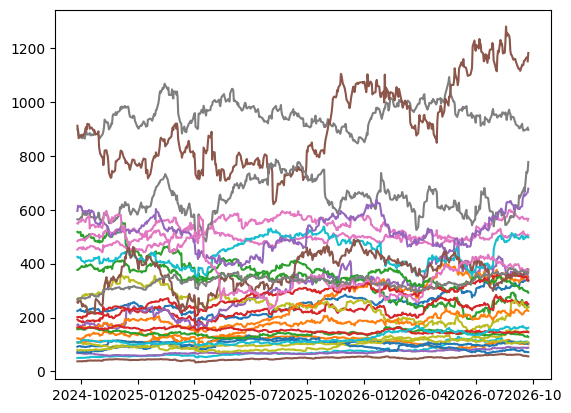

In [5]:
# DO NOT do this if you don't wanna see the current state of the markets :)

plt.plot(prices)

In [6]:
def compute_features(prices):

    returns = prices.pct_change()

    features = {}

    # rolling volatility (10-day)
    features["volatility"] = returns.rolling(10).std()

    # momentum (10-day return)
    features["momentum"] = prices.pct_change(10)

    # rolling z-score of returns
    features["zscore"] = (returns - returns.rolling(10).mean()) / returns.rolling(10).std()

    return features

features = compute_features(prices)

/tmp/ipykernel_755/233062850.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()
/tmp/ipykernel_755/233062850.py:11: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  features["momentum"] = prices.pct_change(10)


In [7]:
def build_matrix(features_dict):
    df_list = []

    for name, df in features_dict.items():

        stacked = df.stack().reset_index()
        stacked.columns = ["date", "ticker", name]

        df_list.append(stacked)

    out = df_list[0]
    for df in df_list[1:]:
        out = out.merge(df, on=["date", "ticker"])

    return out

In [8]:


feature_df = build_matrix(features)

close_df = prices.stack().reset_index()
close_df.columns = ["date", "ticker", "close"]

feature_df = feature_df.merge(close_df, on=["date", "ticker"], how="inner")

In [ ]:
feature_df

,date,ticker,volatility,momentum,zscore,close
0,2024-08-26,AAPL,0.007535,0.044362,-0.381767,225.295349
1,2024-08-26,ABT,0.006731,0.045455,-0.651736,108.076874
2,2024-08-26,ADBE,0.011247,0.053698,-0.289751,559.440002
3,2024-08-26,AMZN,0.017612,0.052158,-0.791120,175.500000
4,2024-08-26,AVGO,0.029646,0.074014,-1.621515,156.673477
...,...,...,...,...,...,...
14724,2026-08-11,TSLA,0.021712,0.082520,-0.107735,332.809998
14725,2026-08-11,UNH,0.013177,-0.062035,-0.737592,402.190002
14726,2026-08-11,V,0.009029,-0.008445,0.756160,362.820007
14727,2026-08-11,WMT,0.010864,0.001415,0.472263,113.260002


In [11]:
from dataclasses import dataclass

@dataclass
class Event:
    type: str
    ticker: str
    start_time: any
    end_time: any
    strength: float
    features: dict
    summary: str

In [12]:
def build_events_from_signal(df, ticker, signal_name, condition_fn, event_type):

    events = []
    in_event = False
    start = None

    df = df.sort_values("date")

    for i, row in df.iterrows():

        active = condition_fn(row)

        if active and not in_event:
            start = row["date"]
            in_event = True

        elif in_event and (not active or i == df.index[-1]): #If we're currently inside an event and the condition becomes false, the event ends.

            end = row["date"]

            segment = df[(df["date"] >= start) & (df["date"] <= end)]

            if len(segment) < 2:
                in_event = False
                continue

            # -------------------------
            # CORE SIGNAL STATS (original)
            # -------------------------
            signal_mean = float(segment[signal_name].mean())
            length = len(segment)

            total_return = float(
                segment["close"].iloc[-1] / segment["close"].iloc[0] - 1
            )

            # -------------------------
            # SAFE EVENT ENRICHMENT (NEW)
            # -------------------------
            returns = segment["close"].pct_change().fillna(0)

            realized_vol = float(returns.std())

            max_drawdown = float(
                (segment["close"] / segment["close"].cummax() - 1).min()
            )

            strength = float(abs(signal_mean) * np.log1p(length))

            # -------------------------
            # EVENT OBJECT
            # -------------------------
            events.append(Event(
                type=event_type,
                ticker=ticker,
                start_time=start,
                end_time=end,
                strength=strength,
                features={
                    f"mean_{signal_name}": signal_mean,
                    f"max_{signal_name}": float(segment[signal_name].max()),
                    "length": length,
                    "total_return": total_return,
                    "realized_vol": realized_vol,
                    "max_drawdown": max_drawdown,
                },
                summary=f"{ticker} {event_type} ({length}d, {total_return:.1%})"
            ))

            in_event = False

    return events

In [13]:
events = []

for ticker, df in feature_df.groupby("ticker"):

    df = df.sort_values("date")

    # volatility events
    events += build_events_from_signal(
        df, ticker, "volatility",
        lambda r: r["volatility"] > df["volatility"].mean() + df["volatility"].std()*2,
        "volatility_regime"
    )

    # momentum events
    events += build_events_from_signal(
        df, ticker, "momentum",
        lambda r: r["momentum"] < df["momentum"].mean() - df["momentum"].std()*2,
        "downtrend_regime"
    )

    # anomaly events
    events += build_events_from_signal(
        df, ticker, "zscore",
        lambda r: abs(r["zscore"]) > 2.5,
        "statistical_stress"
    )

In [14]:
len(events)

313

In [15]:
events[159]

Event(type='statistical_stress', ticker='LLY', start_time=Timestamp('2026-06-26 00:00:00'), end_time=Timestamp('2026-06-29 00:00:00'), strength=1.6493497332409033, features={'mean_zscore': 1.5013028256223806, 'max_zscore': 2.6038758238365762, 'length': 2, 'total_return': 0.01805295829898479, 'realized_vol': 0.012765369233690104, 'max_drawdown': 0.0}, summary='LLY statistical_stress (2d, 1.8%)')

In [16]:
def summarize_events(events):
    summary = {}

    for e in events:
        t = e.type
        summary[t] = summary.get(t, 0) + 1

    return summary

print(summarize_events(events))

{'volatility_regime': 104, 'downtrend_regime': 119, 'statistical_stress': 90}


In [17]:
from dataclasses import dataclass
from typing import List

@dataclass
class CompanyProfile:
    portfolio: List[str]
    risk_tolerance: str
    investment_horizon: str
    objectives: List[str]
    constraints: List[str]

In [18]:
import random

TICKERS = [
    "AAPL","MSFT","NVDA","AMZN","GOOGL","META","TSLA","BRK-B","JPM","V",
    "UNH","XOM","MA","AVGO","PG","HD","LLY","MRK","COST","PEP",
    "ADBE","CSCO","KO","CRM","WMT","BAC","NFLX","TMO","DIS","ABT"
]

RISK_LEVELS = ["low", "medium", "high"]
HORIZONS = ["short_term", "medium_term", "long_term"]

OBJECTIVES = [
    "capital_preservation",
    "steady_growth",
    "income_generation",
    "aggressive_growth"
]

def random_profile():
    return CompanyProfile(
        portfolio=random.sample(TICKERS, k=random.randint(5, 10)),
        risk_tolerance=random.choice(RISK_LEVELS),
        investment_horizon=random.choice(HORIZONS),
        objectives=random.sample(OBJECTIVES, k=2),
        constraints=[]
    )

profile = random_profile()
print(profile)

CompanyProfile(portfolio=['META', 'AAPL', 'AMZN', 'KO', 'PG', 'V', 'UNH', 'NVDA'], risk_tolerance='low', investment_horizon='long_term', objectives=['aggressive_growth', 'income_generation'], constraints=[])


In [19]:
def build_prompt(company_profile, events):

    return f"""
You are an investment firm analytics assistant.

Your task is to analyze this investment firm using:
1. The firm's profile.
2. The observed market events.

Your objective is not to summarize the market, but to determine what these events mean for this specific investment firm.

========================
INVESTMENT FIRM PROFILE
========================

Portfolio:
{company_profile.portfolio}

Risk tolerance:
{company_profile.risk_tolerance}

Investment horizon:
{company_profile.investment_horizon}

Objectives:
{company_profile.objectives}

Constraints:
{company_profile.constraints}

================
OBSERVED EVENTS
================

{events}

========
TASK
========

Analyze the investment firm by interpreting the observed events in the context of the firm's portfolio, objectives, risk tolerance, investment horizon, and constraints.

Produce a structured report with the following sections:

1. Firm Assessment
   - Summarize the firm's current situation.
   - Highlight the most important conclusions.

2. Risks to the Firm
   - Identify the most important risks affecting the firm.
   - Explain why each risk matters for this firm's objectives and portfolio.
   - Support each risk with the relevant events.

3. Opportunities for the Firm
   - Identify opportunities relevant to the firm's strategy.
   - Explain why they matter for this firm.
   - Support each opportunity with the relevant events.

4. Trends Affecting the Firm
   - Identify important market or portfolio trends.
   - Explain how each trend could influence the firm.
   - Support each trend with the relevant events.

5. Portfolio Assessment
   - Assess the portfolio based on the observed events.
   - Highlight strengths, weaknesses, concentrations, and notable observations.

6. Recommended Actions
   - Recommend actions that are consistent with the firm's objectives, investment horizon, and risk tolerance.
   - Justify every recommendation using the observed events.

    - Recommendations must be proportional to the available evidence.
    - Do not recommend buying, selling, increasing, or decreasing positions unless the observed events provide strong, repeated support for such an action.
    - When evidence is limited, recommend monitoring or further investigation instead.

7. Follow-up Analysis

    Identify additional analyses or information that could materially improve the confidence or completeness of this assessment.

    Only recommend follow-up analyses if they have the potential to change or strengthen the conclusions. If the current evidence is sufficient, explicitly state that no further analysis is required.

    Examples of appropriate follow-up analyses include:

    Retrieving events for portfolio holdings that are not represented in the provided event set.
    Extending the observation period to determine whether important events are isolated or recurring.
    Investigating significant market-wide events to distinguish temporary shocks from persistent regime changes.
    Examining sector- or portfolio-level relationships that could materially affect the firm's risk or opportunity assessment.

    For each suggested follow-up analysis, explain:

    What additional information should be obtained.
    Why it could materially improve the assessment.
    Which conclusions it is expected to validate, refine, or challenge.

8. Retrieval Request

  If additional events could materially improve this assessment, output a retrieval request using the following format:

  retrieval_request = {{
      "tickers": [...],          # or null
      "event_types": [...],      # or null
      "start_time": "...",       # or null
      "end_time": "...",         # or null
      "reason": "..."
  }}

  Rules for retrieval requents:
  - Only request additional events if they could materially change or strengthen the assessment.
  - Request only the minimum information necessary.
  - Use only the fields shown above.
  - If no additional events are needed, set:
    retrieval_request = null.

Rules:
- Use only the provided events. If an event is not provided but should be, state so in the Follow up Analysis section.
- Interpret every finding relative to this investment firm.
- Do not simply list events; synthesize them into meaningful insights.
- Support every conclusion with the relevant events.
- If evidence is limited or conflicting, explicitly state the uncertainty.
"""

In [20]:
def reduce_events(events, k=30):
    from collections import defaultdict

    by_type = defaultdict(list)

    for e in events:
        by_type[e.type].append(e)

    # compute weights per type
    type_weight = {
        t: sum(e.strength for e in group)
        for t, group in by_type.items()
    }

    total_weight = sum(type_weight.values())

    reduced = []

    for t, group in by_type.items():
        share = max(1, int(k * type_weight[t] / total_weight))

        group_sorted = sorted(group, key=lambda e: e.strength, reverse=True)
        reduced.extend(group_sorted[:share])

    return sorted(reduced, key=lambda e: e.strength, reverse=True)[:k]

In [21]:
events_reduced = reduce_events(events, k=5)
print(len(events_reduced))

5


In [22]:
company_profile = random_profile()

In [23]:

#company_profile = random_profile()
#prompt = build_prompt(company_profile, events_small)
prompt = build_prompt(company_profile, events_reduced)

In [27]:
retrieval_request = {
    "tickers": ["BRK-B", "KO", "ADBE", "TSLA", "ABT", "AMZN", "PG"],
    "event_types": ["statistical_stress", "downtrend_regime"],
    "start_time": "2024-12-10 00:00:00",
    "end_time": "2025-10-01 00:00:00",
    "reason": "The supplied events cover only 3 of the 10 portfolio holdings. Events for the remaining holdings over the observed period could materially change the assessment of portfolio-wide risk, diversification, and whether the observed UNH/CSCO weakness is concentrated or part of a broader portfolio trend."
}

In [28]:
import pandas as pd

def retrieve_events(
    events,
    tickers=None,
    event_types=None,
    start_time=None,
    end_time=None,
    reason=None
):
    if start_time is not None:
        start_time = pd.Timestamp(start_time)

    if end_time is not None:
        end_time = pd.Timestamp(end_time)

    retrieved = []

    for event in events:

        if tickers is not None and event.ticker not in tickers:
            continue

        if event_types is not None and event.type not in event_types:
            continue

        if start_time is not None and event.end_time < start_time:
            continue

        if end_time is not None and event.start_time > end_time:
            continue

        retrieved.append(event)

    return retrieved

In [29]:
new_events = retrieve_events(events, **retrieval_request)

new_events = reduce_events(new_events, k=30)